In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols, logit
import joblib


Korean files are encoded in a different format, so I use encoding="cp949" to read them correctly. Trying to open them using the common UTF-8 encoding replaces Korean characters with different symbols.

In [2]:
# Loading raw data
raw_data = pd.read_csv(r"C:\Users\stbbr\Desktop\Nueva carpeta\Proyectos\Programación\Smoking\raw_smoking.CSV", encoding="cp949")

In [3]:
# Showing columns names
raw_data.columns

Index(['기준년도', '가입자일련번호', '시도코드', '성별코드', '연령대코드(5세단위)', '신장(5cm단위)',
       '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '청력(좌)', '청력(우)', '수축기혈압',
       '이완기혈압', '식전혈당(공복혈당)', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤',
       '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태',
       '음주여부', '구강검진수검여부', '치아우식증유무', '결손치 유무', '치아마모증유무', '제3대구치(사랑니) 이상',
       '치석'],
      dtype='object')

Column names are in Korean. Since I don't know Korean, I used a combination of Google Translate and kukuroo3/body-signal-of-smoking to translate them.

In [4]:
# Getting the raw DataFrame with translated column names
english_raw = raw_data.copy()
english_raw.columns = ['Reference year', 'ID', 'Province', 'Gender', 'Age', 'Height',
    'Weight', 'Waist', 'Vision(left)', 'Vision(right)', 'Hearing(left)', 'Hearing(right)', 'Systolic_blood_pressure',
    'Diastolic_blood_pressure', 'Fasting_blood_glucose', 'Total_cholesterol', 'Triglycerides', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Hemoglobin', 'Urine_protein',
    'Serum_creatinine', 'AST(Aspartate_Aminotransferase)', 'ALT_(Alanine_Aminotransferase)', 'Gamma-GTP (Gamma-Glutamyl_Transferase)', 'Smoking_status', 'Alcohol_status',
    'Oral_examination_status', 'Dental_caries_presence', 'Missing_teeth', 'Tooth_wear', 'Third_molar(wisdom_tooth)_abnormality', 'Dental_calculus(Tartar)']

print(english_raw.sample(5))

        Reference year       ID  Province  Gender  Age  Height  Weight  Waist  \
77649             2024  1985319        11       2    6     155      50   67.0   
674287            2024  4118671        41       1    9     185      80   82.0   
471240            2024  2421208        27       1   14     165      70   87.0   
957136            2024  4206677        41       1   11     165      70   86.0   
265384            2024  4535873        46       2   12     160      70   85.0   

        Vision(left)  Vision(right)  ...  ALT_(Alanine_Aminotransferase)  \
77649            0.7            1.2  ...                            17.0   
674287           1.0            1.0  ...                            17.0   
471240           1.5            0.9  ...                            32.0   
957136           1.0            1.0  ...                            27.0   
265384           0.8            1.0  ...                            27.0   

        Gamma-GTP (Gamma-Glutamyl_Transferase)  Smoking_

In [5]:
# Getting a statistical summary of the raw data
print(english_raw.describe())

       Reference year            ID        Province          Gender  \
count       1000000.0  1.000000e+06  1000000.000000  1000000.000000   
mean           2024.0  2.499783e+06       33.924477        1.482070   
std               0.0  1.443848e+06       12.509850        0.499679   
min            2024.0  9.000000e+00       11.000000        1.000000   
25%            2024.0  1.247716e+06       27.000000        1.000000   
50%            2024.0  2.499856e+06       41.000000        1.000000   
75%            2024.0  3.749790e+06       43.000000        2.000000   
max            2024.0  5.000000e+06       49.000000        2.000000   

                  Age          Height          Weight          Waist  \
count  1000000.000000  1000000.000000  1000000.000000  999505.000000   
mean        10.671586      162.732935       64.563640      81.564217   
std          3.066531        9.355593       14.020046      10.941088   
min          5.000000      130.000000       30.000000       6.800000   


In [6]:
# Checking which gender each number represents by comparing it with kukuroo3/body-signal-of-smoking
english_raw[['ID', 'Age']].sort_values(by='Age')

,ID,Age
563890,3177294,5
31240,3233338,5
31238,2731368,5
31252,4687545,5
31249,1104196,5
...,...,...
644968,3486236,18
952319,959082,18
143797,319024,18
999963,3383525,18


1 corresponds to Male, 2 corresponds to Female

The columns 'Missing teeth', 'Tooth wear' and 'Third molar (wisdom tooth) abnormality' are empty, so I remove them.

The Age column indicates the age group each patient belongs to rather than their actual age. Multiplying it by 5 gives the upper limit of that age group. Therefore, the patient's actual age is just below that value.

In [7]:
clean_df = english_raw.copy()

# Dropping empty columns
clean_df = clean_df.dropna(axis=1, how='all')

# Converting the values to the desired format
clean_df['Gender'] = np.where(clean_df['Gender'] == 1, 'M', 'F')

clean_df['Smoking_status'] = clean_df['Smoking_status'].astype(str)
clean_df['Smoking_status'] = np.where(clean_df['Smoking_status'] == '1.0', 'Non-smoker', clean_df['Smoking_status'])
clean_df['Smoking_status'] = np.where(clean_df['Smoking_status'] == '2.0', 'Former smoker', clean_df['Smoking_status'])
clean_df['Smoking_status'] = np.where(clean_df['Smoking_status'] == '3.0', 'Current smoker', clean_df['Smoking_status'])

clean_df['Alcohol_status'] = clean_df['Alcohol_status'].astype(str)
clean_df['Alcohol_status'] = np.where(clean_df['Alcohol_status'] == '0.0', 'Non-drinker', clean_df['Alcohol_status'])
clean_df['Alcohol_status'] = np.where(clean_df['Alcohol_status'] == '1.0', 'Drinker', clean_df['Alcohol_status'])

# Adding a Body Mass Index column
clean_df['BMI'] = clean_df['Weight'] / (clean_df['Height']**2)

# Displaying the DataFrame dimensions and statistical summary
print(clean_df.shape)
print(clean_df.describe())

(1000000, 31)
       Reference year            ID        Province             Age  \
count       1000000.0  1.000000e+06  1000000.000000  1000000.000000   
mean           2024.0  2.499783e+06       33.924477       10.671586   
std               0.0  1.443848e+06       12.509850        3.066531   
min            2024.0  9.000000e+00       11.000000        5.000000   
25%            2024.0  1.247716e+06       27.000000        8.000000   
50%            2024.0  2.499856e+06       41.000000       11.000000   
75%            2024.0  3.749790e+06       43.000000       13.000000   
max            2024.0  5.000000e+06       49.000000       18.000000   

               Height          Weight          Waist   Vision(left)  \
count  1000000.000000  1000000.000000  999505.000000  999807.000000   
mean       162.732935       64.563640      81.564217       0.953090   
std          9.355593       14.020046      10.941088       0.575464   
min        130.000000       30.000000       6.800000       0.1

I'm calculating whether each patient has metabolic syndrome based on:
https://www.ncbi.nlm.nih.gov/sites/books/NBK278936/

For waist circumference, I'm using: https://pmc.ncbi.nlm.nih.gov/articles/PMC2858833/

In [8]:
# Cut-off values for considering a metabolic syndrome risk factor
# Values above these thresholds are considered risk factors.
cut_off_high_dicc = {
    'Waist_M' : 87,
    'Waist_W' : 83,
    'Triglycerides' : 150,
    'Systolic_blood_pressure' : 130,
    'Diastolic_blood_pressure' : 85,
    'Fasting_blood_glucose' : 100 
}

# Values below these thresholds are considered risk factors.
cut_off_low_dicc = {
    'HDL_Cholesterol_M' : 40,
    'HDL_Cholesterol_W' : 50
}

In [9]:
met_syn_df = clean_df.copy()

# Adding a new column with the number of risk factors for each patient
met_syn_df['Risk_factors'] = 0
for cutt_off_col in cut_off_high_dicc.keys():
    if cutt_off_col in met_syn_df.columns:
        met_syn_df['Risk_factors'] = np.where(met_syn_df[cutt_off_col] >= cut_off_high_dicc[cutt_off_col], met_syn_df['Risk_factors'] + 1, met_syn_df['Risk_factors'])
    else:
        if '_F' in cutt_off_col:
            actual_col = cutt_off_col.replace('_F', '')
            met_syn_df['Risk_factors'] = np.where((met_syn_df[actual_col] >= cut_off_high_dicc[cutt_off_col]) & (met_syn_df['Gender'] == 'F'), met_syn_df['Risk_factors'] + 1, met_syn_df['Risk_factors'])
        elif '_M' in cutt_off_col:
            actual_col = cutt_off_col.replace('_M', '')
            met_syn_df['Risk_factors'] = np.where((met_syn_df[actual_col] >= cut_off_high_dicc[cutt_off_col]) & (met_syn_df['Gender'] == 'M'), met_syn_df['Risk_factors'] + 1, met_syn_df['Risk_factors'])

for cutt_off_col in cut_off_low_dicc.keys():
    if '_F' in cutt_off_col:
        actual_col = cutt_off_col.replace('_F', '')
        met_syn_df['Risk_factors'] = np.where((met_syn_df[actual_col] <= cut_off_low_dicc[cutt_off_col]) & (met_syn_df['Gender'] == 'F'), met_syn_df['Risk_factors'] + 1, met_syn_df['Risk_factors'])
    elif '_M' in cutt_off_col:
        actual_col = cutt_off_col.replace('_M', '')
        met_syn_df['Risk_factors'] = np.where((met_syn_df[actual_col] <= cut_off_low_dicc[cutt_off_col]) & (met_syn_df['Gender'] == 'M'), met_syn_df['Risk_factors'] + 1, met_syn_df['Risk_factors'])

# Adding a metabolic syndrome column, assigning a value of 1 to patients with the syndrome and 0 to those without it
met_syn_df["Metabolic_Syndrome"] = (met_syn_df["Risk_factors"] >= 3).astype(int) # I'll assign a value of 1 if the patient has metabolic syndrome, and 0 otherwise

To avoid misdiagnosing metabolic syndrome in cases with missing information, I'll remove those rows.

In [10]:
# Since I've converted the Alcohol_status and Smoking_status columns to strings, I remove the rows containing the text 'nan'
alc_smo_df = met_syn_df[(met_syn_df['Alcohol_status']!='nan') & (met_syn_df['Smoking_status']!='nan')].copy()

# For the remaining columns, I drop NaN values as usual
alc_smo_df = alc_smo_df.dropna(subset=['Waist', 'Triglycerides', 'Systolic_blood_pressure', 'Diastolic_blood_pressure', 'Fasting_blood_glucose', 'HDL_Cholesterol'], how='any')

# Adding a new column combining alcohol and smoking status
alc_smo_df['Alcohol/Smoking_status'] = alc_smo_df['Alcohol_status'] + ', ' + alc_smo_df['Smoking_status']
print(alc_smo_df['Alcohol/Smoking_status'].unique())

['Non-drinker, Non-smoker' 'Drinker, Non-smoker' 'Drinker, Former smoker'
 'Drinker, Current smoker' 'Non-drinker, Current smoker'
 'Non-drinker, Former smoker']


In [11]:
# Checking the final dimensions of the data
print(alc_smo_df.shape)

(342304, 34)


In [12]:
# Saving the DataFrame as a CSV file for use in other projects
alc_smo_df.to_csv('smoking_df_english.csv', sep=';')

In [13]:
# Statistical summary by alcohol and smoking status
for comb in alc_smo_df['Alcohol/Smoking_status'].unique():
    temp_df = alc_smo_df[alc_smo_df['Alcohol/Smoking_status']==comb]
    print(comb)
    print(temp_df['Risk_factors'].describe())

Non-drinker, Non-smoker
count    106233.000000
mean          1.317736
std           1.179855
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: Risk_factors, dtype: float64
Drinker, Non-smoker
count    109805.000000
mean          1.311953
std           1.317078
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: Risk_factors, dtype: float64
Drinker, Former smoker
count    49628.000000
mean         2.013601
std          1.459206
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: Risk_factors, dtype: float64
Drinker, Current smoker
count    51635.000000
mean         2.127782
std          1.510425
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: Risk_factors, dtype: float64
Non-drinker, Current smoker
count    11015.000000

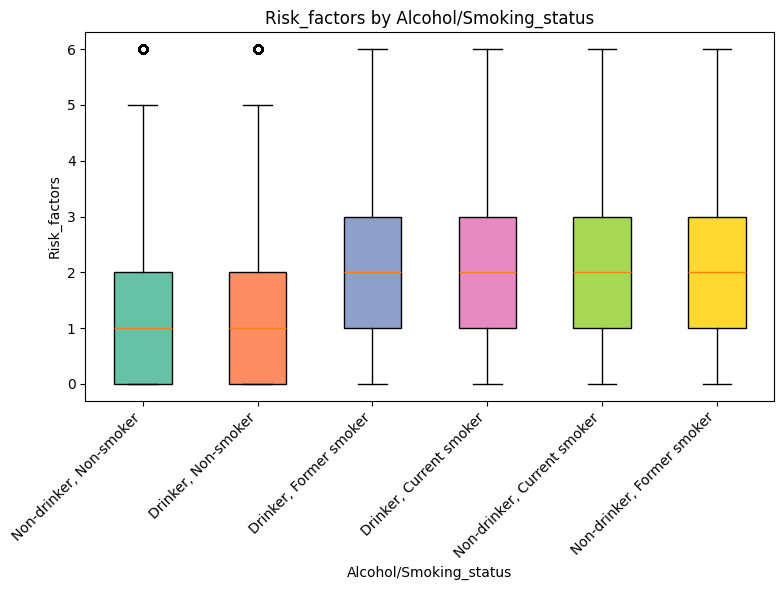

In [14]:
# Creating the boxplot for the previous statistical summary
fig, ax = plt.subplots(figsize=(8, 6))

groups = alc_smo_df['Alcohol/Smoking_status'].unique()

data = [alc_smo_df.loc[alc_smo_df['Alcohol/Smoking_status'] == group, 'Risk_factors'].dropna() for group in groups]

bp = ax.boxplot(
    data,
    tick_labels=alc_smo_df['Alcohol/Smoking_status'].unique(),
    patch_artist=True
)

colors = plt.cm.Set2(range(len(groups)))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel('Alcohol/Smoking_status')
ax.set_ylabel('Risk_factors')
ax.set_title('Risk_factors by Alcohol/Smoking_status')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

It is clearly shown that non-smokers generally have fewer metabolic syndrome risk factors.

I'm creating a model to identify which characteristics are associated with the number of risk factors. Since waist circumference is used to calculate the risk factors, I'm not including physical attributes (height, weight, or BMI) in the model to avoid circular reasoning.

In [15]:
# Creating a model to evaluate the importance of different variables in predicting the number of risk factors
model = ols(
    'Risk_factors ~ C(Alcohol_status) + C(Smoking_status) + C(Alcohol_status):C(Smoking_status) + C(Gender) + Age',
    data=alc_smo_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

# Calculating the partial effect
ss_res = anova_table.loc["Residual", "sum_sq"]
anova_table["size_effect"] = (
    anova_table["sum_sq"] /
    (anova_table["sum_sq"] + ss_res)
)

# Dropping the Residual row, as it is not meaningful for some of these values
anova_table = anova_table.drop(index="Residual", columns=["sum_sq", "df"])

print(anova_table)

                                                F        PR(>F)  size_effect
C(Alcohol_status)                       98.999983  2.543542e-23     0.000289
C(Smoking_status)                     1090.011310  0.000000e+00     0.006329
C(Gender)                            32563.970065  0.000000e+00     0.086870
C(Alcohol_status):C(Smoking_status)    214.544110  7.638858e-94     0.001252
Age                                  11538.463748  0.000000e+00     0.032610


Every variable included in the model contributes significantly (P < 0.05). The F statistic and effect size indicate how much of the variability is explained by each variable.

0.03% for Alcohol status

0.63% for Smoking status

8.69% for Gender

0.13% for the interaction between Alcohol and Smoking status

3.26% for Age

Gender and Age are the strongest predictors of the number of risk factors. Smoking status has a statistically significant but relatively small effect, whereas Alcohol status and its interaction with Smoking status are also significant but contribute only marginally to the explained variance. This indicates that, despite their extremely small p-values, the practical importance of alcohol-related effects is limited compared with Gender and Age.

In [16]:
# Creating a logistic regression model to predict metabolic syndrome (Risk factors ≥ 3)
model = logit(
    "Metabolic_Syndrome ~ C(Alcohol_status) + \
     C(Smoking_status) + \
     C(Alcohol_status):C(Smoking_status) + \
     Gender + Age",
    data=alc_smo_df
).fit()

Optimization terminated successfully.
         Current function value: 0.500367
         Iterations 6


In [17]:
joblib.dump(model, "model.pkl", compress=3)

['model.pkl']